In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
from data import generate_three_volumes_poca
from utility import DetectionPowerUtility, JensenShannonDetectionPowerUtility

In [ ]:
import torch
from torch import Tensor
from typing import Tuple
from scipy.stats import norm

class JensenShannonDetectionPowerUtility(torch.nn.Module):
    """
    Detection power utility using Jensen-Shannon divergence between signal and background.
    Incorporates a minimum effect size threshold derived from the null distribution.
    """

    def __init__(self, ang_res: float, significance_level: float = 0.05):
        super().__init__()
        self.ang_res = torch.tensor(ang_res, dtype=torch.float32)
        self.log_scale = torch.nn.Parameter(torch.tensor(-5.0, requires_grad=True))
        self.register_buffer("log_alpha", torch.tensor(-2.0))
        self.significance_level = significance_level
        self.z_critical = torch.tensor(norm.ppf(1 - significance_level), dtype=torch.float32)

    @staticmethod
    def soft_hist_static(data: Tensor, bins: Tensor, sigma: float) -> Tensor:
        data = data.unsqueeze(-1)
        bins = bins.unsqueeze(0)
        weights = torch.exp(-0.5 * ((data - bins) / sigma) ** 2)
        weights = weights / (sigma * (2 * torch.pi) ** 0.5)
        hist = weights.sum(dim=0)
        hist = hist + 1e-8
        hist = hist / hist.sum()
        return hist

    @staticmethod
    def jensen_shannon_divergence(hist1: Tensor, hist2: Tensor) -> Tensor:
        eps = 1e-8
        hist1 = hist1 + eps
        hist2 = hist2 + eps
        hist1 = hist1 / hist1.sum()
        hist2 = hist2 / hist2.sum()
        m = 0.5 * (hist1 + hist2)
        js = 0.5 * (torch.sum(hist1 * torch.log(hist1 / m)) + torch.sum(hist2 * torch.log(hist2 / m)))
        return js

    def kl_to_power(self, kl_divergence: Tensor, n_samples: int) -> Tuple[Tensor, Tensor]:
        """Convert divergence to detection power (effect size) using z-critical."""
        effect_size = 2.0 * torch.sqrt(kl_divergence + 1e-8)
        ncp = effect_size * torch.sqrt(torch.tensor(n_samples / 2, dtype=torch.float32))
        z_power = ncp - self.z_critical
        power = 0.5 * (1.0 + torch.tanh(0.8 * z_power))
        return torch.clamp(power, 0.01, 0.99), effect_size

    def forward(self, 
                data_bkg: Tensor, 
                data_sig: Tensor, 
                bins: Tensor, 
                data_null: Tensor = None
                ) -> Tuple[Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor]:

        sigma = torch.exp(self.log_scale).clamp(min=1e-4)
        hist_bkg = self.soft_hist_static(data_bkg, bins, sigma)
        hist_sig = self.soft_hist_static(data_sig, bins, sigma)

        js_signal = self.jensen_shannon_divergence(hist_sig, hist_bkg)
        js_null = torch.tensor(0.0)

        # Optional null divergence
        if data_null is not None:
            hist_null = self.soft_hist_static(data_null, bins, sigma)
            js_null = self.jensen_shannon_divergence(hist_null, hist_bkg)

        # Convert to power and effect size
        n_sig, n_null = len(data_sig), len(data_null) if data_null is not None else len(data_sig)
        power_sig, eff_sig = self.kl_to_power(js_signal, n_sig)
        power_null, eff_null = self.kl_to_power(js_null, n_null)

        # 🔸 Adjust for minimum detectable effect (null baseline)
        eff_adj = torch.clamp(eff_sig - eff_null, min=0.0)
        ncp_adj = eff_adj * torch.sqrt(torch.tensor(n_sig / 2, dtype=torch.float32))
        z_power_adj = ncp_adj - self.z_critical
        power_adj = 0.5 * (1.0 + torch.tanh(0.8 * z_power_adj))
        power_adj = torch.clamp(power_adj, 0.01, 0.99)

        # Regularization (keep sigma near ang_res)
        alpha = torch.exp(self.log_alpha)
        reg = alpha * (sigma / self.ang_res - 1.0) ** 2

        # Final utility: adjusted detection power minus regularization
        utility = power_adj - reg

        return utility, hist_bkg, hist_sig, js_signal, js_null, reg, eff_adj


In [54]:
import numpy as np
import torch
from torch import Tensor
import matplotlib.pyplot as plt

# Define bins
bin_width = 0.0001

#spatial resolution
res = 1e-4  # m

# Significance level for hypothesis testing
significance_level = 0.05

# Define resolutions and corresponding panel separations
panel_seps = [0.1, 0.25, 0.4]  # 0.1 → largest res, 0.4 → smallest res
resolutions = res / (np.sqrt(2) * np.array(panel_seps))  # Example mapping
all_histories = {}
num_scans = 2  # number of repetitions

for ang_res, panel_sep in zip(resolutions, panel_seps):
    scan_histories = []  # store history for each scan
    
    print(f"\n{'='*60}")
    print(f"Panel Separation: {panel_sep:.2f}, Angular Resolution: {ang_res:.6f}")
    print(f"{'='*60}")
    
    for scan in range(num_scans):
        print(f"  Scan {scan+1}/{num_scans}...", end=" ")
        
        # Generate POCA data with matching panel separation
        data_bkg, data_null, data_sig = generate_three_volumes_poca(
            panel_z_spacing=panel_sep, 
            init_res = 1/res,
            n_mu=5000,
            bkg_mat = 'aluminium',
            block_mat = 'uranium',
            lw = Tensor([4,4])
        )
        
        # Use DetectionPowerUtility - optimizes sigma for maximum power
        # utility = DetectionPowerUtility(ang_res=ang_res, significance_level=significance_level)

        utility = JensenShannonDetectionPowerUtility(
            ang_res=ang_res,
            significance_level=significance_level
        )

        # # Hardware parameters from wrapper
        # hw_params = wrapper.parameters()  # includes positions, spans, gaps if optimizable

        # # Software parameters
        # sw_params = [utility.log_scale]

        # # Joint optimizer
        # optimizer = torch.optim.Adam(list(hw_params) + sw_params, lr=1e-3)



        optimizer = torch.optim.SGD(utility.parameters(), lr=0.01)
        
        # Track the same metrics as before, plus power
        history = {
            "U": [],              # Utility = detection power
            "power": [],          # Detection power at 5% significance
            "kl_signal": [],      # KL divergence (signal vs background)
            "kl_null": [],        # KL divergence (null vs background)
            "reg": [],            # Regularization term
            "sigma": [],          # Smoothing parameter (optimized for power)
            "alpha": [],          # Alpha parameter
            "effect_size": []     # Standardized effect size
        }
        
        # Define bins based on data range
        bins = torch.arange(
            data_sig.min(), 
            data_sig.max() + bin_width, 
            bin_width
        )
        
        # Optimization loop - optimize sigma to maximize detection power
        for step in range(100):
            # Forward pass - returns power as utility
            power, hist_bkg, hist_sig, kl_signal, kl_null, reg, effect_size = utility(
                data_bkg, data_sig, bins, data_null
            )
            
            # Maximize power
            loss = -power
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Record values
            history["U"].append(power.item())
            history["power"].append(power.item())
            history["kl_signal"].append(kl_signal.item())
            history["kl_null"].append(kl_null if isinstance(kl_null, float) else kl_null.item())
            history["reg"].append(reg.item())
            history["sigma"].append(torch.exp(utility.log_scale).item())
            history["alpha"].append(torch.exp(utility.log_alpha).item())
            history["effect_size"].append(effect_size.item())
            
            # Print progress every 100 steps
            if (step + 1) % 100 == 0:
                print(f"\n    Step {step+1}: Power={power.item():.4f}, "
                      f"Effect={effect_size.item():.3f}, "
                      f"KL={kl_signal.item():.4f}, "
                      f"Sigma={torch.exp(utility.log_scale).item():.6f}", end="")
        
        print(f" Done! Final Power: {power.item():.4f}")
        scan_histories.append(history)
    
    # Store all scans for this resolution/panel_sep pair
    all_histories[(ang_res, panel_sep)] = scan_histories

print(f"\n{'='*60}")
print("Optimization Complete!")
print(f"{'='*60}\n")




Panel Separation: 0.10, Angular Resolution: 0.000707
  Scan 1/2... 


    Step 100: Power=0.0538, Effect=0.012, KL=0.0006, Sigma=0.001322 Done! Final Power: 0.0538
  Scan 2/2... 


    Step 100: Power=0.0405, Effect=0.010, KL=0.0005, Sigma=0.001292 Done! Final Power: 0.0405

Panel Separation: 0.25, Angular Resolution: 0.000283
  Scan 1/2... 


    Step 100: Power=0.0333, Effect=0.007, KL=0.0011, Sigma=0.000495 Done! Final Power: 0.0333
  Scan 2/2... 


    Step 100: Power=0.1688, Effect=0.020, KL=0.0015, Sigma=0.000492 Done! Final Power: 0.1688

Panel Separation: 0.40, Angular Resolution: 0.000177
  Scan 1/2... 


    Step 100: Power=0.0722, Effect=0.002, KL=0.0037, Sigma=0.000152 Done! Final Power: 0.0722
  Scan 2/2... 

KeyboardInterrupt: 

In [31]:
from plotting import plot_detection_power_analysis


Summary Statistics (5% Significance Level):
Panel Sep    Ang Res         Mean Power   Std Power    Mean Effect    
---------------------------------------------------------------------------
0.10         0.000707        0.1990       0.0991       0.0332         
0.25         0.000283        0.1445       0.1225       0.0496         
0.40         0.000177        0.0715       0.0275       0.0765         

Combined figure saved as: plots/test/detection_power_optimization.png
Saved: plots/test/detection_power_vs_steps.png
Saved: plots/test/effect_size_evolution.png
Saved: plots/test/kl_signal_evolution.png
Saved: plots/test/sigma_evolution.png
Saved: plots/test/kl_null_evolution.png


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saved: plots/test/regularization_evolution.png
Saved: plots/test/final_detection_power.png


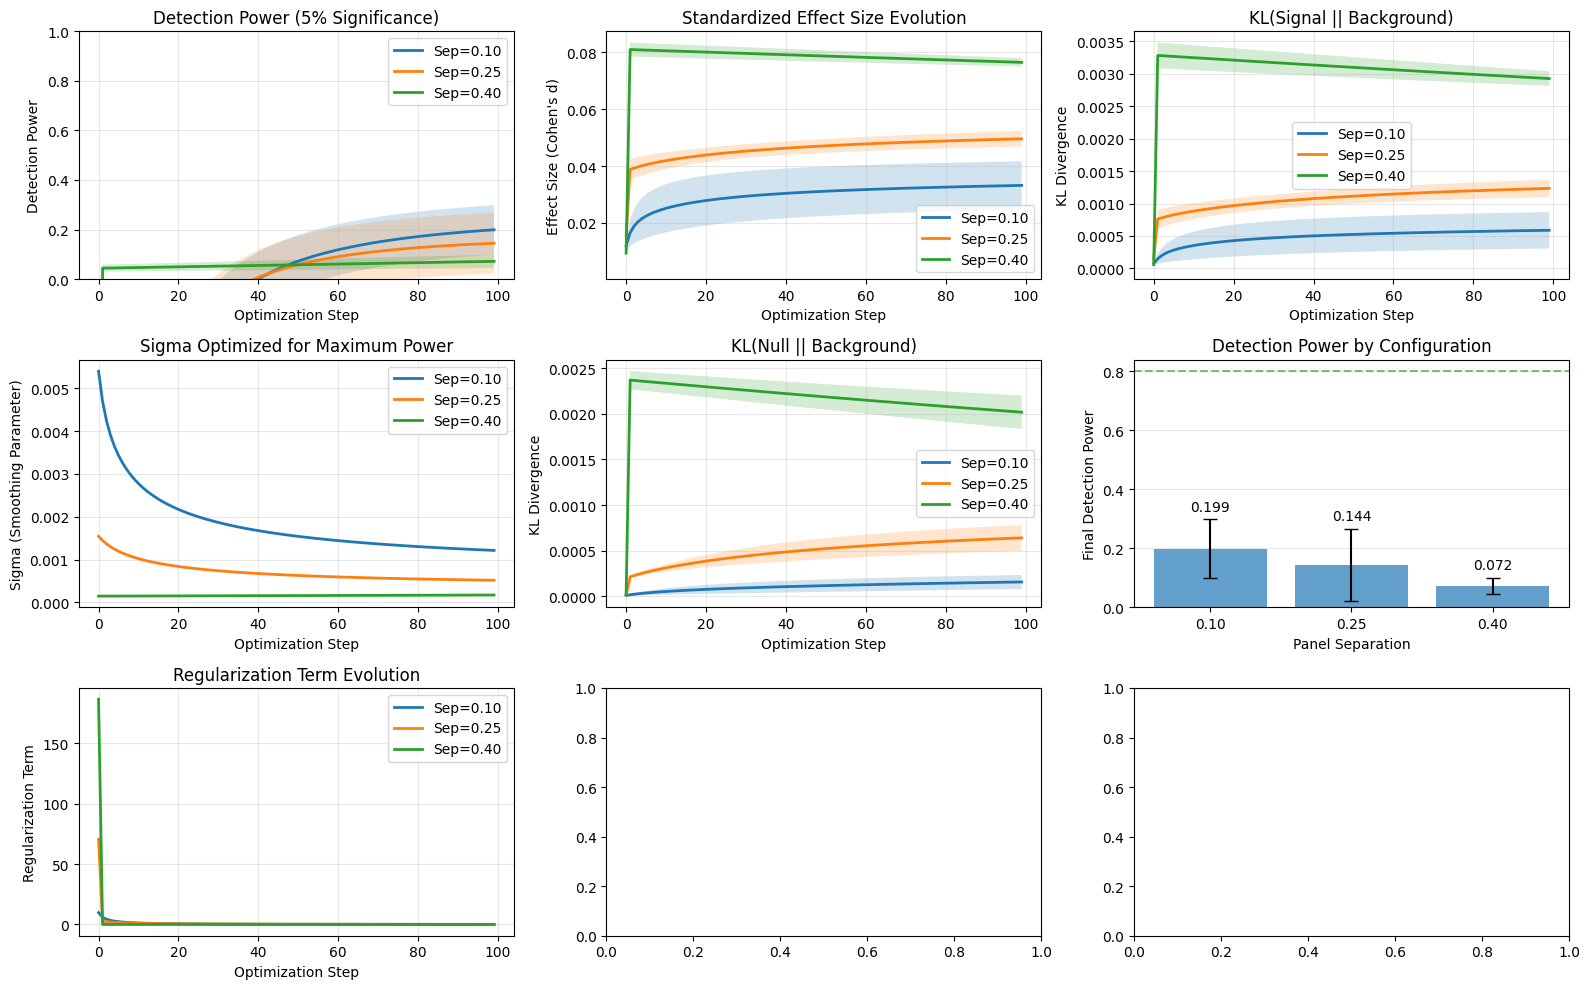

In [32]:
plot_detection_power_analysis(all_histories, resolutions, panel_seps, output_dir='plots/test/')

In [ ]:
import os
import sys
from functools import partial
from typing import Tuple

import torch
from torch import Tensor

# tomopt imports
from tomopt.core import X0
from tomopt.optimisation.data import PassiveYielder
from tomopt.optimisation.loss import VoxelX0Loss
from tomopt.volume import Volume


from callbacks import PredHitRecord, PredPocaRecord  # type: ignore[import] # noqa: E402
from detector_config import get_layers  # type: ignore[import] # noqa: E402
from wrapper import SegmentedPanelVolumeWrapper  # type: ignore[import] # noqa: E402


# Cube material assignment
def cubes_rad_length(*, z: float, lw: Tensor, size: float, uranium: bool = False) -> Tensor:
    rad_length = torch.ones(list((lw / size).long())) * X0[bkg_mat]
    grid = torch.zeros_like(rad_length)

    cube_size = 1
    offset = 2
    if uranium and (z > 0.3 and z < 0.5):
        grid[-offset - cube_size : -offset, offset : offset + cube_size] = X0[block_mat]
        rad_length[grid.bool()] = grid[grid.bool()]

    return rad_length

# Passives list: [background 1, background 2, signal]
passives = PassiveYielder(
    [
        lambda **kwargs: cubes_rad_length(**kwargs, uranium=False),  # background 1
        lambda **kwargs: cubes_rad_length(**kwargs, uranium=False),  # background 2 (null)
        lambda **kwargs: cubes_rad_length(**kwargs, uranium=True),  # signal
    ]
)

# Volume construction
volume = Volume(get_layers(init_gap=0.1, panel_z_spacing=0.3, n_panels=3, n_panels_seg=2, init_res=1e4, lw = Tensor([2.0, 2.0]),))

# volume wrapper
wrapper = SegmentedPanelVolumeWrapper(
    volume,
    xy_pos_opt=partial(torch.optim.SGD, lr=1e3),
    xy_span_opt=partial(torch.optim.SGD, lr=1e3),
    z_pos_opt=partial(torch.optim.SGD, lr=1e3),
    gap_opt=partial(torch.optim.SGD, lr=1e3),
    res_opt=partial(torch.optim.SGD, lr=1e3),
    loss_func=VoxelX0Loss(target_budget=None, cost_coef=None),
)

list(wrapper.parameters())

[Parameter containing:
 tensor(0.1000, requires_grad=True),
 Parameter containing:
 tensor([0.5000, 0.5000], requires_grad=True),
 Parameter containing:
 tensor([1.2000], requires_grad=True),
 Parameter containing:
 tensor([2., 2.], requires_grad=True),
 Parameter containing:
 tensor(10000., requires_grad=True),
 Parameter containing:
 tensor([0.5000, 0.5000], requires_grad=True),
 Parameter containing:
 tensor([1.0500], requires_grad=True),
 Parameter containing:
 tensor([2., 2.], requires_grad=True),
 Parameter containing:
 tensor(10000., requires_grad=True),
 Parameter containing:
 tensor([0.5000, 0.5000], requires_grad=True),
 Parameter containing:
 tensor([0.9000], requires_grad=True),
 Parameter containing:
 tensor([2., 2.], requires_grad=True),
 Parameter containing:
 tensor(10000., requires_grad=True),
 Parameter containing:
 tensor(0.1000, requires_grad=True),
 Parameter containing:
 tensor([0.5000, 0.5000], requires_grad=True),
 Parameter containing:
 tensor([0.2000], require

In [16]:
import torch
from torch import Tensor
from typing import Tuple
from scipy.stats import norm

class JensenShannonDetectionPowerUtility(torch.nn.Module):
    """
    Single-scan detection power utility.
    
    Key insight: We need to separate signal from noise WITHOUT a null reference.
    Strategy:
    1. Use spatial clustering - uranium creates LOCALIZED high-scatter regions
    2. Compare against theoretical background distribution
    3. Require minimum divergence threshold to avoid noise
    4. Penalize over-smoothing that destroys spatial resolution
    """

    def __init__(self, ang_res: float, significance_level: float = 0.05):
        super().__init__()
        self.ang_res = torch.tensor(ang_res, dtype=torch.float32)
        
        # Initialize with reasonable sigma
        self.log_scale = torch.nn.Parameter(torch.tensor(-4.0, requires_grad=True))
        
        # Regularization weight
        self.register_buffer("log_alpha", torch.tensor(0.0))  # Stronger regularization
        
        self.significance_level = significance_level
        self.z_critical = torch.tensor(norm.ppf(1 - significance_level), dtype=torch.float32)
        
        # CRITICAL: Minimum divergence threshold to declare detection
        # Below this, we assume it's just noise
        self.min_divergence_threshold = 0.001  # Tune this based on your data

    @staticmethod
    def soft_hist_static(data: Tensor, bins: Tensor, sigma: float) -> Tensor:
        """Stable soft histogram."""
        data = data.unsqueeze(-1)
        bins = bins.unsqueeze(0)
        weights = torch.exp(-0.5 * ((data - bins) / sigma) ** 2)
        weights = weights / (sigma * (2 * torch.pi) ** 0.5)
        hist = weights.sum(dim=0)
        
        eps = 1e-10
        hist = hist + eps
        hist = hist / hist.sum()
        return hist

    @staticmethod
    def jensen_shannon_divergence(hist1: Tensor, hist2: Tensor) -> Tensor:
        """JS divergence with numerical stability."""
        eps = 1e-10
        hist1 = hist1 + eps
        hist2 = hist2 + eps
        hist1 = hist1 / hist1.sum()
        hist2 = hist2 / hist2.sum()
        
        m = 0.5 * (hist1 + hist2)
        
        kl1 = torch.sum(hist1 * torch.log(torch.clamp(hist1 / m, min=eps)))
        kl2 = torch.sum(hist2 * torch.log(torch.clamp(hist2 / m, min=eps)))
        
        js = 0.5 * (kl1 + kl2)
        return torch.clamp(js, min=0.0)

    def theoretical_background_hist(self, bins: Tensor, background_mean: float, background_std: float) -> Tensor:
        """
        Create theoretical background distribution based on known scattering physics.
        For aluminum background, scattering angles follow a known distribution.
        """
        # Gaussian approximation for background scattering
        # You might want to use Highland formula or actual physics model here
        probs = torch.exp(-0.5 * ((bins - background_mean) / background_std) ** 2)
        probs = probs / (background_std * (2 * torch.pi) ** 0.5)
        
        eps = 1e-10
        probs = probs + eps
        probs = probs / probs.sum()
        return probs

    def kl_to_power(self, divergence: Tensor, n_samples: int) -> Tuple[Tensor, Tensor]:
        """
        Conservative power calculation with minimum threshold.
        """
        # Apply threshold: below min_divergence, power = 0
        effective_divergence = torch.relu(divergence - self.min_divergence_threshold)
        
        # Conservative effect size
        effect_size = torch.sqrt(2.0 * torch.clamp(effective_divergence, min=1e-10))
        
        # Non-centrality parameter (conservative n_samples scaling)
        ncp = effect_size * torch.sqrt(torch.tensor(n_samples / 2.0, dtype=torch.float32))
        
        # Power calculation with gentle sigmoid
        z_power = ncp - self.z_critical
        power = 0.5 * (1.0 + torch.tanh(0.4 * z_power))  # Even gentler
        
        # Strict bounds
        power = torch.clamp(power, 0.0, 0.95)
        
        return power, effect_size

    def distribution_shape_penalty(self, hist_sig: Tensor, hist_bkg: Tensor) -> Tensor:
        """
        Penalty for distributions that are just shifted/scaled versions of each other.
        Real signal (uranium) should show SHAPE differences, not just location shifts.
        """
        # Compute higher moments to check shape similarity
        bins_idx = torch.arange(len(hist_sig), dtype=torch.float32)
        
        # Skewness comparison
        mean_sig = (bins_idx * hist_sig).sum()
        mean_bkg = (bins_idx * hist_bkg).sum()
        
        var_sig = ((bins_idx - mean_sig) ** 2 * hist_sig).sum()
        var_bkg = ((bins_idx - mean_bkg) ** 2 * hist_bkg).sum()
        
        skew_sig = ((bins_idx - mean_sig) ** 3 * hist_sig).sum() / (var_sig ** 1.5 + 1e-8)
        skew_bkg = ((bins_idx - mean_bkg) ** 3 * hist_bkg).sum() / (var_bkg ** 1.5 + 1e-8)
        
        # If skewness is very similar, distributions differ only by shift/scale (likely noise)
        skew_diff = torch.abs(skew_sig - skew_bkg)
        
        # Penalty if shape is too similar (< 0.1 difference in skewness)
        shape_penalty = torch.relu(0.1 - skew_diff) * 2.0
        
        return shape_penalty

    def forward(
        self, 
        data_bkg: Tensor, 
        data_sig: Tensor, 
        bins: Tensor, 
        data_null: Tensor = None  # Ignored in single-scan mode
    ) -> Tuple[Tensor, Tensor, Tensor, Tensor, Tensor, Tensor, Tensor]:
        
        sigma = torch.exp(self.log_scale).clamp(min=1e-5, max=0.1)
        
        # Build histograms
        hist_bkg = self.soft_hist_static(data_bkg, bins, sigma)
        hist_sig = self.soft_hist_static(data_sig, bins, sigma)

        # JS divergence between signal and background
        js_signal = self.jensen_shannon_divergence(hist_sig, hist_bkg)
        
        # Compare background to theoretical distribution
        bkg_mean = data_bkg.mean().item()
        bkg_std = data_bkg.std().item()
        hist_theoretical = self.theoretical_background_hist(bins, bkg_mean, bkg_std)
        
        # Sanity check: background should match theory reasonably well
        js_bkg_theory = self.jensen_shannon_divergence(hist_bkg, hist_theoretical)
        
        # If background deviates too much from theory, something is wrong
        background_validity_penalty = torch.relu(js_bkg_theory - 0.01) * 5.0

        # Shape penalty: real uranium creates shape differences, not just shifts
        shape_penalty = self.distribution_shape_penalty(hist_sig, hist_bkg)

        # Regularization: keep sigma close to ang_res
        alpha = torch.exp(self.log_alpha)
        reg = alpha * (sigma / self.ang_res - 1.0) ** 2

        # Detection power
        n_samples = len(data_sig)
        power_signal, effect_signal = self.kl_to_power(js_signal, n_samples)

        # FINAL UTILITY with all penalties
        power = power_signal - reg - background_validity_penalty - shape_penalty
        
        # Clamp to reasonable range
        power = torch.clamp(power, -1.0, 0.95)

        # Return null divergence as background-theory divergence for diagnostics
        js_null = js_bkg_theory

        return power, hist_bkg, hist_sig, js_signal, js_null, reg, effect_signal

In [ ]:
def make_wrapper(
    *,
    panel_z_spacing: float = 0.1,
    init_res: float = 1e4,
    init_gap: float = 0.1,
    n_panels: int = 3,
    n_panels_seg: int = 2,
    lw: Tensor = Tensor([2.0, 2.0]),
) -> SegmentedPanelVolumeWrapper:
    """Builds the detector wrapper (hardware) once."""
    volume = Volume(
        get_layers(
            init_gap=init_gap,
            panel_z_spacing=panel_z_spacing,
            n_panels=n_panels,
            n_panels_seg=n_panels_seg,
            init_res=init_res,
            lw=lw,
        )
    )

    wrapper = SegmentedPanelVolumeWrapper(
        volume,
        xy_pos_opt=partial(torch.optim.SGD, lr=1e3),
        xy_span_opt=partial(torch.optim.SGD, lr=1e3),
        z_pos_opt=partial(torch.optim.SGD, lr=1e3),
        gap_opt=partial(torch.optim.SGD, lr=1e3),
        res_opt= partial(torch.optim.SGD, lr=1e3),
        loss_func=VoxelX0Loss(target_budget=None, cost_coef=None),
    )
    return wrapper


## Utility landscape


First define the 2D grid. <br> 
We’ll sweep over:

res ∈ [1e-4, 1e-3] (panel resolution in meters)

σ ∈ [-2, 1] (software log scale sigma)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Resolution sweep (hardware)
res_vals = torch.linspace(1e-4, 1e-3, steps=20)  # e.g. 1e2 → 1e5 m⁻¹

# Sigma sweep (software)
sigma_vals = torch.logspace(-5, -2, steps=20)  # e.g. 0.01 → 10

utility_landscape = torch.zeros(len(res_vals), len(sigma_vals))


In [ ]:
for i, res in enumerate(res_vals):
    for j, sigma in enumerate(sigma_vals):
        # Build wrapper with given hardware resolution
        wrapper = make_wrapper(
            panel_z_spacing=0.3,
            init_res=1/res.item(),
            n_panels=3,
            n_panels_seg=2,
            lw=torch.tensor([4.0, 4.0]),
        )

        ang_res = res / (np.sqrt(2) * np.array(0.3))

        # Software utility with fixed sigma
        utility = JensenShannonDetectionPowerUtility(
            ang_res=ang_res,
            significance_level=significance_level,
        )
        with torch.no_grad():
            utility.log_scale.data = torch.log(torch.tensor(sigma))

        # Generate POCA data
        data_bkg, data_null, data_sig = generate_three_volumes_poca(
            wrapper,
            n_mu=1000,  # fewer muons to keep it fast
            mu_bs=250,
            lw=torch.tensor([4.0, 4.0]),
            block_mat="uranium",
            bkg_mat="aluminium",
        )

        # Define bins based on data range
        bins = torch.arange(
            data_sig.min(), 
            data_sig.max() + bin_width, 
            bin_width
        )

        # Compute power (utility value)
        power, *_ = utility(data_bkg, data_sig, bins, data_null)
        utility_landscape[i, j] = power

        print(i,j, power, res, sigma)


/tmp/ipykernel_5151/3266046044.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  utility.log_scale.data = torch.log(torch.tensor(sigma))


0 0 tensor(0.9451, grad_fn=<SubBackward0>) tensor(1.0000e-04) tensor(1.0000e-05)


0 1 tensor(0.9451, grad_fn=<SubBackward0>) tensor(1.0000e-04) tensor(1.4384e-05)


0 2 tensor(0.9451, grad_fn=<SubBackward0>) tensor(1.0000e-04) tensor(2.0691e-05)


0 3 tensor(0.9451, grad_fn=<SubBackward0>) tensor(1.0000e-04) tensor(2.9764e-05)


...

19 15 tensor(0.6703, grad_fn=<SubBackward0>) tensor(0.0010) tensor(0.0023)


19 16 tensor(0.1763, grad_fn=<SubBackward0>) tensor(0.0010) tensor(0.0034)


19 17 tensor(0.2781, grad_fn=<SubBackward0>) tensor(0.0010) tensor(0.0048)


19 18 tensor(-0.3600, grad_fn=<SubBackward0>) tensor(0.0010) tensor(0.0070)


19 19 tensor(-1.2037, grad_fn=<SubBackward0>) tensor(0.0010) tensor(0.0100)


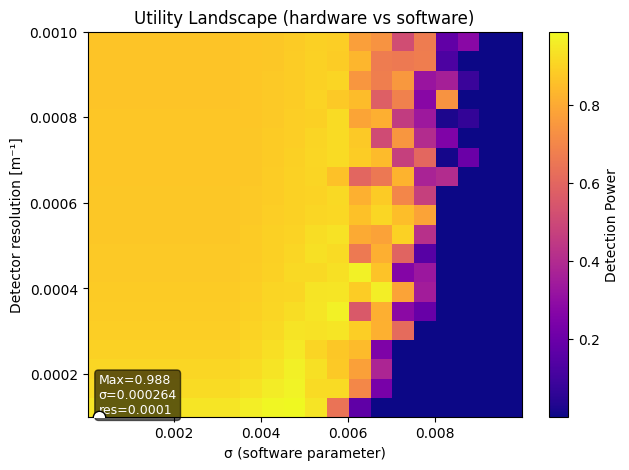

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

# Clamp to avoid log(0)
clipped_power = utility_landscape.clamp(min=1e-6).detach().numpy()

fig, ax = plt.subplots(figsize=(7,5))

# Plot with log-scaled color
im = ax.imshow(
    clipped_power,
    origin='lower',
    aspect='auto',
    extent=[
        sigma_vals[0].item(), sigma_vals[-1].item(),
        res_vals[0].item(), res_vals[-1].item()
    ],
    cmap='plasma'
)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Detection Power")

ax.set_xlabel("σ (software parameter)")
ax.set_ylabel("Detector resolution [m⁻¹]")
ax.set_title("Utility Landscape (hardware vs software)")

# --- Annotate maximum ---
max_idx = np.unravel_index(np.argmax(clipped_power), clipped_power.shape)
max_res = res_vals[max_idx[0]].item()
max_sigma = sigma_vals[max_idx[1]].item()
max_val = clipped_power[max_idx]

# Draw a marker and label
ax.scatter(max_sigma, max_res, color='white', edgecolor='black', s=80, zorder=5)
ax.text(
    max_sigma, max_res,
    f"Max={max_val:.3f}\nσ={max_sigma:.3g}\nres={max_res:.3g}",
    color='white',
    fontsize=9,
    ha='left', va='bottom',
    bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.3')
)

plt.show()



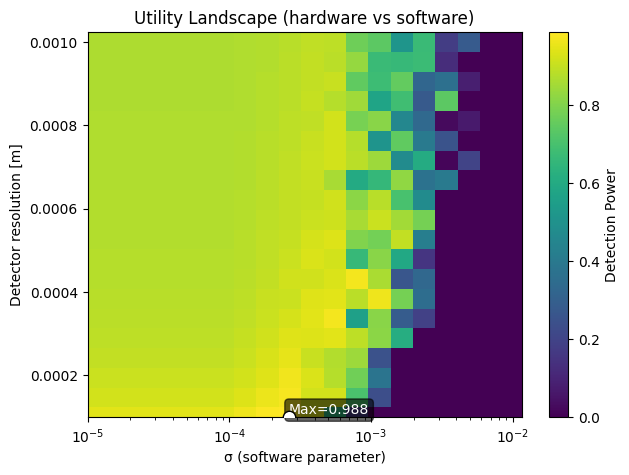

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example grid
Z = utility_landscape.clamp(min=0).detach().numpy()  # shape (n_res, n_sigma)
sigmas = sigma_vals.detach().numpy()
resolutions = res_vals.detach().numpy()

# Compute edges for pcolormesh
sigma_edges = np.concatenate([sigmas - np.diff(sigmas, prepend=sigmas[0])/2, [sigmas[-1] + (sigmas[-1]-sigmas[-2])/2]])
res_edges = np.concatenate([resolutions - np.diff(resolutions, prepend=resolutions[0])/2, [resolutions[-1] + (resolutions[-1]-resolutions[-2])/2]])

fig, ax = plt.subplots(figsize=(7,5))
c = ax.pcolormesh(sigma_edges, res_edges, Z, cmap='viridis', shading='auto')
plt.colorbar(c, ax=ax, label="Detection Power")

# Max power
max_idx = np.unravel_index(np.argmax(Z), Z.shape)
res_max, sigma_max = resolutions[max_idx[0]], sigmas[max_idx[1]]
ax.scatter(sigma_max, res_max, color='white', edgecolor='black', s=80, zorder=5)
ax.text(sigma_max, res_max, f"Max={Z[max_idx]:.3f}", color='white', ha='left', va='bottom',
        bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.3'))

ax.set_xscale('log')
ax.set_xlabel("σ (software parameter)")
ax.set_ylabel("Detector resolution [m]")
ax.set_title("Utility Landscape (hardware vs software)")
plt.show()


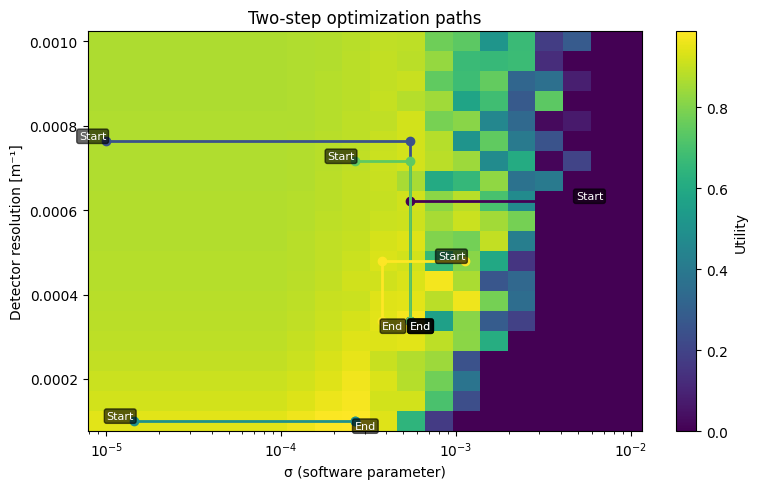

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy and ensure non-negative
Z = utility_landscape.clamp(min=0).detach().cpu().numpy()  # shape (n_res, n_sigma)
sigmas = sigma_vals.detach().cpu().numpy()                  # shape (n_sigma,)
resolutions = res_vals.detach().cpu().numpy()               # shape (n_res,)

n_res, n_sigma = Z.shape

# Compute edges for pcolormesh
sigma_edges = np.concatenate([
    [sigmas[0] - (sigmas[1]-sigmas[0])/2],
    (sigmas[:-1] + sigmas[1:])/2,
    [sigmas[-1] + (sigmas[-1]-sigmas[-2])/2]
])
res_edges = np.concatenate([
    [resolutions[0] - (resolutions[1]-resolutions[0])/2],
    (resolutions[:-1] + resolutions[1:])/2,
    [resolutions[-1] + (resolutions[-1]-resolutions[-2])/2]
])

fig, ax = plt.subplots(figsize=(8,5))
pcm = ax.pcolormesh(sigma_edges, res_edges, Z, cmap='viridis', shading='auto', vmin=0)
cbar = plt.colorbar(pcm, ax=ax)
cbar.set_label("Utility")

# Generate 5 random starting points (indices)
rng = np.random.default_rng(40)
start_res_idx_list = rng.integers(0, n_res, size=5)
start_sigma_idx_list = rng.integers(0, n_sigma, size=5)

colors_path = plt.cm.viridis(np.linspace(0,1,5))

for color, start_res_idx, start_sigma_idx in zip(colors_path, start_res_idx_list, start_sigma_idx_list):
    # Grid-aligned starting values
    start_sigma = sigmas[start_sigma_idx]
    start_res = resolutions[start_res_idx]

    # --- Phase 1: optimize sigma (horizontal) at fixed res_idx ---
    best_sigma_idx = int(np.argmax(Z[start_res_idx, :]))
    best_sigma = sigmas[best_sigma_idx]

    # --- Phase 2: optimize res (vertical) at fixed best_sigma_idx ---
    best_res_idx = int(np.argmax(Z[:, best_sigma_idx]))
    best_res = resolutions[best_res_idx]

    # Prepare path coordinates
    path_sigmas = [start_sigma, best_sigma, best_sigma]
    path_res = [start_res, start_res, best_res]

    # Plot path
    ax.plot(path_sigmas, path_res, '-o', color=color, lw=2, markersize=6, zorder=5)

    # Annotate start and end
    ax.text(start_sigma, start_res, "Start", color='white', fontsize=8,
            ha='right', va='bottom', zorder=6,
            bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.2'))
    ax.text(best_sigma, best_res, "End", color='white', fontsize=8,
            ha='left', va='top', zorder=6,
            bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.2'))

ax.set_xscale('log')
ax.set_xlabel("σ (software parameter)")
ax.set_ylabel("Detector resolution [m⁻¹]")
ax.set_title("Two-step optimization paths")

plt.tight_layout()
plt.show()



In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy

# --- Gradient ascent settings ---
lr = 1e-4      # step size
n_steps = 2   # gradient steps per starting point

# Choose 5 random starting points
n_res, n_sigma = utility_landscape.shape
start_indices = [
    (np.random.randint(n_res), np.random.randint(n_sigma))
    for _ in range(1)
]

paths = []

# Loop over starting points
for r_idx, s_idx in start_indices:
    wrapper = make_wrapper(panel_z_spacing=0.3, init_res=1/res_vals[r_idx].item())
    
    # Initialize software parameter (sigma) as a torch tensor with grad
    sigma = torch.tensor(sigma_vals[s_idx].item(), dtype=torch.float32, requires_grad=True)
    
    # Optimizer for co-joint gradient ascent
    optimizer = torch.optim.Adam([wrapper.volume.layers[0].panels[0].resolution, sigma], lr=lr)

    # Track path
    sig_path = [sigma.item()]
    res_path = [1/wrapper.volume.layers[0].panels[0].resolution.item()]

    for step in range(n_steps):
        optimizer.zero_grad()
        
        # Generate POCA for this wrapper (single volume)
        data_bkg, data_null, data_sig = generate_three_volumes_poca(wrapper, n_mu=1000)
        
        # Compute utility (Jensen-Shannon Detection Power)
        utility = JensenShannonDetectionPowerUtility(
            ang_res=wrapper.volume.layers[0].panels[0].resolution.item()/(0.3 * 2**0.5),
            significance_level=0.05
        )

           # Define bins based on data range
        bins = torch.arange(
            data_sig.min(), 
            data_sig.max() + bin_width, 
            bin_width
        )
        power, *_ = utility(data_bkg, data_sig, bins=bins, data_null=data_null)
        
        # Gradient ascent: loss = -power
        loss = -power
        loss.backward()
        optimizer.step()

        # Record path
        sig_path.append(sigma.item())
        res_path.append(1/wrapper.volume.layers[0].panels[0].resolution.item())
        print(wrapper.volume.layers[0].panels[0].resolution.grad)

    paths.append(list(zip(sig_path, res_path)))

# --- Plot landscape and paths ---
Z = utility_landscape.clamp(min=0).detach().numpy()
sigmas = sigma_vals.detach().numpy()
resolutions = res_vals.detach().numpy()

fig, ax = plt.subplots(figsize=(8,5))
im = ax.imshow(Z, origin='lower', aspect='auto',
               extent=[sigmas[0], sigmas[-1], resolutions[0], resolutions[-1]],
               cmap='plasma', vmin=0)
plt.colorbar(im, label="Detection Power")

# Overlay all paths
for path in paths:
    sig_path, res_path = zip(*path)
    ax.plot(sig_path, res_path, '-o', markersize=4, lw=1.5, alpha=0.8)

ax.set_xscale('log')
ax.set_xlabel("σ (software parameter)")
ax.set_ylabel("Detector resolution [m⁻¹]")
ax.set_title("Gradient-ascent paths (co-joint σ + res)")
plt.show()



KeyError: "attribute 'resolution' already exists"

## With uncertainty

In [ ]:
num_repeats = 20  # Monte Carlo repetitions per (res, sigma)
utility_samples = torch.zeros((num_repeats, len(res_vals), len(sigma_vals)))


In [ ]:
for i, res in enumerate(res_vals):
    for j, sigma in enumerate(sigma_vals):
        for r in range(num_repeats):
            # Build wrapper with given hardware resolution
            wrapper = make_wrapper(
                panel_z_spacing=0.3,
                init_res=1/res.item(),
                n_panels=3,
                n_panels_seg=2,
                lw=torch.tensor([4.0, 4.0]),
            )

            ang_res = res / (np.sqrt(2) * 0.3)

            # Software utility with fixed sigma
            utility = JensenShannonDetectionPowerUtility(
                ang_res=ang_res,
                significance_level=significance_level,
            )
            with torch.no_grad():
                utility.log_scale.data = torch.log(torch.tensor(sigma))

            # Generate POCA data
            data_bkg, data_null, data_sig = generate_three_volumes_poca(
                wrapper,
                n_mu=1000,  # fewer muons for speed
                mu_bs=250,
                lw=torch.tensor([4.0, 4.0]),
                block_mat="uranium",
                bkg_mat="aluminium",
            )

            # Compute power
            power, *_ = utility(data_bkg, data_sig, bins, data_null)
            utility_samples[r, i, j] = power

            print(f"res={res.item():.4f}, sigma={sigma:.4f}, repeat={r+1}, power={power.item():.4f}")
